In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
# Membaca data CSV
data = pd.read_csv('/content/data_iklim - Sheet1.csv')
# Melihat 5 data pertama
print(data.head())

  precipitation max temperature min temperature         wind  \
0   22,17864727          22,579          16,226   0,98477418   
1   10,77861942          29,369         20,2985  1,054619598   
2   9,443091888          27,384           18,62  0,999835774   
3   15,51303961         21,7585         14,9085  0,922273123   
4   15,21262902          24,568          17,651  1,078517568   

  relative humidity        solar  
0       0,949216707  12,98674041  
1       0,837694214  20,63957504  
2       0,869631027  18,48553254  
3        0,95195662  9,497525996  
4       0,927156092  15,35485704  


In [9]:
data.rename(columns={'precipitation': 'Y', 'max temperature': 'X1', 'min temperature': 'X2','wind': 'X3','relative humidity': 'X4', 'solar': 'X5'  }, inplace=True)
print(data)

              Y       X1       X2           X3           X4           X5
0   22,17864727   22,579   16,226   0,98477418  0,949216707  12,98674041
1   10,77861942   29,369  20,2985  1,054619598  0,837694214  20,63957504
2   9,443091888   27,384    18,62  0,999835774  0,869631027  18,48553254
3   15,51303961  21,7585  14,9085  0,922273123   0,95195662  9,497525996
4   15,21262902   24,568   17,651  1,078517568  0,927156092  15,35485704
..          ...      ...      ...          ...          ...          ...
73  12,59995248    28,55   27,616  4,894644163  0,778710263   24,5863831
74  15,13280583   28,394  27,4405  5,250058221  0,782320956  24,46784926
75  10,98633383   28,297    27,32  5,626392953  0,784487412  23,70526639
76  9,758090113  28,4465  27,4975  5,078008382  0,777538741  23,12369102
77  8,621691253  28,6175   27,674  4,858509463   0,76938309  22,73527942

[78 rows x 6 columns]


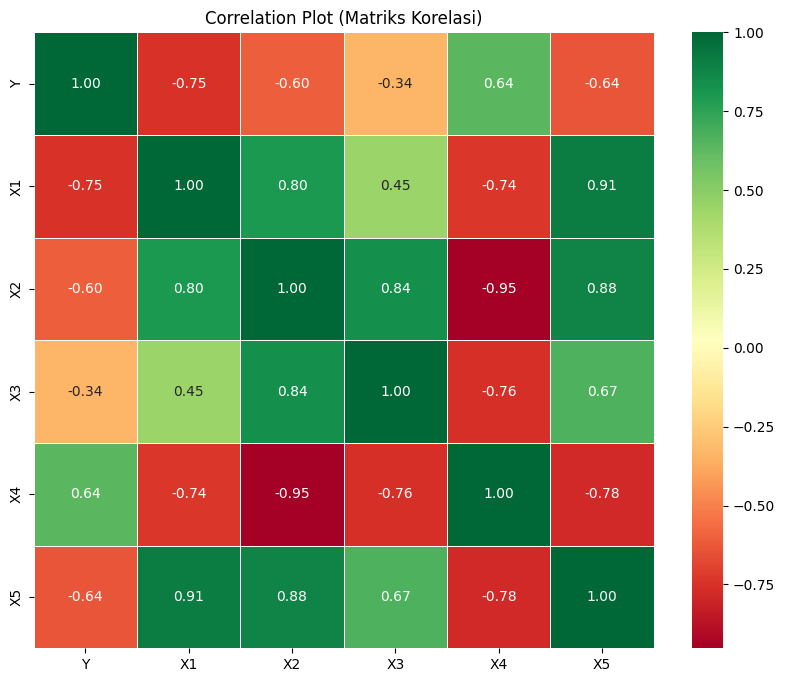

In [11]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.replace(',', '.', regex=False).astype(float)

plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Correlation Plot (Matriks Korelasi)")
plt.show()


  Interpretasi Korelasi:

   Lihat kolom Y: Variabel dengan nilai mendekati 1 atau -1 memiliki hubungan kuat dengan curah hujan.
Jika ada hubungan antar X yang > 0.8, waspadai multikolinearitas.






In [12]:
X = data[['X1', 'X2', 'X3', 'X4', 'X5']]
X_with_const = sm.add_constant(X) # Menambah intercept
y = data['Y']

model = sm.OLS(y, X_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     27.72
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.55e-15
Time:                        12:47:53   Log-Likelihood:                -164.19
No. Observations:                  78   AIC:                             340.4
Df Residuals:                      72   BIC:                             354.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.9870     16.485     -0.545      0.5

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Variabel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\n[Asumsi 1: Non-Multikolinearitas]")
print(vif_data)


[Asumsi 1: Non-Multikolinearitas]
  Variabel          VIF
0       X1  1292.202050
1       X2   556.846948
2       X3    31.131414
3       X4   168.178527
4       X5   162.619475


Interpretasi: VIF > 10 menunjukkan adanya multikolinearitas yang kuat, terutama pada X1, X2, X4 dan X5. Perlu dilakukan penanganan lebih lanjut.

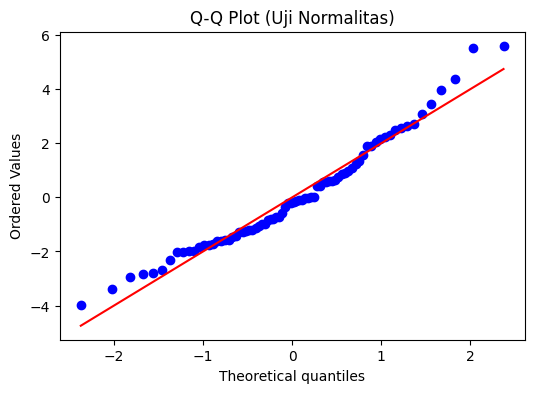

In [14]:
plt.figure(figsize=(6, 4))
stats.probplot(model.resid, dist="norm", plot=plt)
plt.title("Q-Q Plot (Uji Normalitas)")
plt.show()

Interpretasi: Jika titik mengikuti garis merah, maka residual berdistribusi normal.

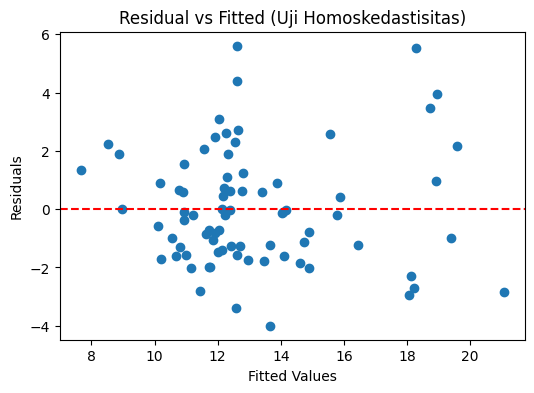

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted (Uji Homoskedastisitas)')
plt.show()

Interpretasi: Jika titik menyebar acak tanpa pola corong, maka asumsi terpenuhi.

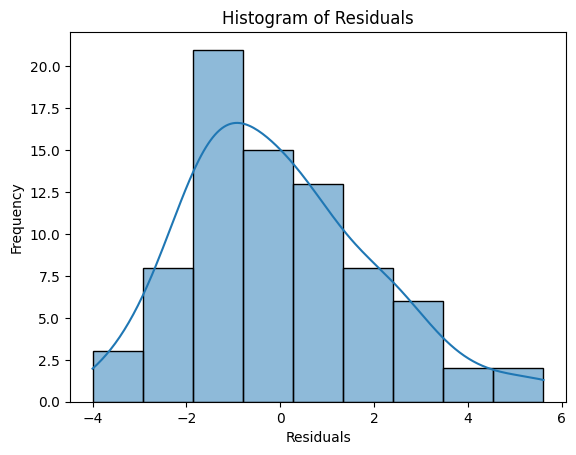

Shapiro-Wilk Test: W=0.966, p-value=0.035


In [16]:
# Plot Histogram Residual
residuals_ln = model.resid
sns.histplot(residuals_ln, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test_ln = stats.shapiro(residuals_ln)
print(f'Shapiro-Wilk Test: W={shapiro_test_ln[0]:.3f}, p-value={shapiro_test_ln[1]:.3f}')

Grafik menunjukkan distribusi residual. Meskipun terlihat berbentuk lonceng, ada sedikit kemiringan (skewness) ke arah kanan.